# Week 6 Assignment - Image Denoising with Autoencoders

**Name:** Parth Moholkar
**Track:** Data Science Internship, Celebal Technologies

## Objective
Train an autoencoder to remove noise from MNIST digit images, and compare a dense (fully-connected) architecture against a convolutional one.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Loading MNIST
Loaded directly through Keras's built-in loader, which pulls from a Google-hosted mirror - no separate dataset download or zip file needed.

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

x_train_conv = x_train.reshape(-1, 28, 28, 1)
x_test_conv = x_test.reshape(-1, 28, 28, 1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 3. Adding Noise
Gaussian noise is added to every image, then pixel values are clipped back to a valid 0-1 range. The autoencoders are trained to map this noisy version back to the original clean image.

In [3]:
noise_factor = 0.5

def add_noise(images):
    noisy = images + noise_factor * np.random.normal(size=images.shape)
    return np.clip(noisy, 0.0, 1.0)

x_train_noisy_flat = add_noise(x_train_flat)
x_test_noisy_flat = add_noise(x_test_flat)

x_train_noisy_conv = x_train_noisy_flat.reshape(-1, 28, 28, 1)
x_test_noisy_conv = x_test_noisy_flat.reshape(-1, 28, 28, 1)

## 4. Clean vs Noisy Samples

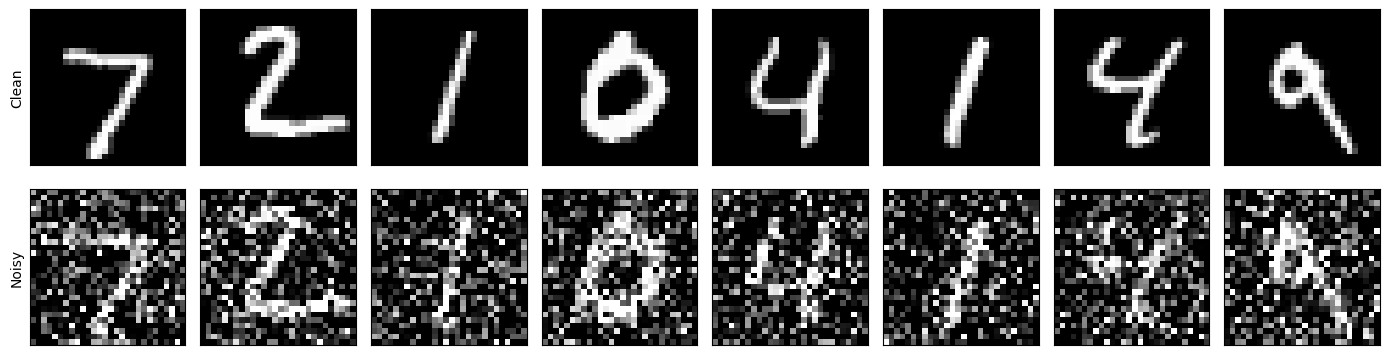

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(x_test[i], cmap='gray')
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    axes[1, i].imshow(x_test_noisy_flat[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

axes[0, 0].set_ylabel("Clean")
axes[1, 0].set_ylabel("Noisy")
plt.tight_layout()
plt.show()

## 5. Shared Training Callbacks

In [5]:
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]

## 6. Model A - Dense Autoencoder
A flattened 784-pixel vector is compressed down to 64 values and expanded back out. Binary crossentropy is used as the loss since the sigmoid output keeps every pixel in the 0-1 range, which it handles better in practice than a plain squared-error loss for this kind of reconstruction.

In [6]:
def build_dense_autoencoder(encoding_dim=64):
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(encoding_dim, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(784, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])
    return model

dense_model = build_dense_autoencoder()
dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,536 (1.66 MB)

 Trainable params: 435,536 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
dense_history = dense_model.fit(
    x_train_noisy_flat, x_train_flat,
    validation_data=(x_test_noisy_flat, x_test_flat),
    epochs=30,
    batch_size=128,
    callbacks=make_callbacks(),
    verbose=1
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.1966 - mse: 0.0443 - val_loss: 0.1433 - val_mse: 0.0264 - learning_rate: 0.0010
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1356 - mse: 0.0238 - val_loss: 0.1280 - val_mse: 0.0214 - learning_rate: 0.0010
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1258 - mse: 0.0206 - val_loss: 0.1220 - val_mse: 0.0195 - learning_rate: 0.0010
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1206 - mse: 0.0190 - val_loss: 0.1184 - val_mse: 0.0183 - learning_rate: 0.0010
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1175 - mse: 0.0179 - val_loss: 0.1162 - val_mse: 0.0176 - learning_rate: 0.0010
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.1152 - mse: 0.0172 - val_loss: 0.1148 - val_mse: 0.0172 - learning_rate: 0.0010
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.1134 - mse: 0.0166 - val_loss: 0.1128 - val_mse: 0.0165 - learning_rate: 0.0010

## 7. Model B - Convolutional Autoencoder
Convolution and pooling keep the 2D layout of the image intact instead of flattening it, which usually helps recover sharper detail. Upsampling followed by a convolution is used on the decoder side rather than a transposed convolution, since transposed convolutions are known to introduce checkerboard artifacts.

In [8]:
def build_conv_autoencoder():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, padding='same'),
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2, padding='same'),

        layers.UpSampling2D(2),
        layers.Conv2D(16, 3, activation='relu', padding='same'),
        layers.UpSampling2D(2),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(1, 3, activation='sigmoid', padding='same')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])
    return model

conv_model = build_conv_autoencoder()
conv_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
conv_history = conv_model.fit(
    x_train_noisy_conv, x_train_conv,
    validation_data=(x_test_noisy_conv, x_test_conv),
    epochs=30,
    batch_size=128,
    callbacks=make_callbacks(),
    verbose=1
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 95s 199ms/step - loss: 0.1652 - mse: 0.0331 - val_loss: 0.1187 - val_mse: 0.0182 - learning_rate: 0.0010
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 199ms/step - loss: 0.1160 - mse: 0.0173 - val_loss: 0.1118 - val_mse: 0.0160 - learning_rate: 0.0010
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 194ms/step - loss: 0.1111 - mse: 0.0157 - val_loss: 0.1078 - val_mse: 0.0147 - learning_rate: 0.0010
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 199ms/step - loss: 0.1078 - mse: 0.0146 - val_loss: 0.1055 - val_mse: 0.0140 - learning_rate: 0.0010
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 198ms/step - loss: 0.1059 - mse: 0.0140 - val_loss: 0.1042 - val_mse: 0.0135 - learning_rate: 0.0010
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 199ms/step - loss: 0.1047 - mse: 0.0136 - val_loss: 0.1034 - val_mse: 0.0133 - learning_rate: 0.0010
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 194ms/step - loss: 0.1038 - mse: 0.0133 - val_loss: 0.1027 - val_mse: 0.0130 - lea

## 8. Validation Loss Comparison

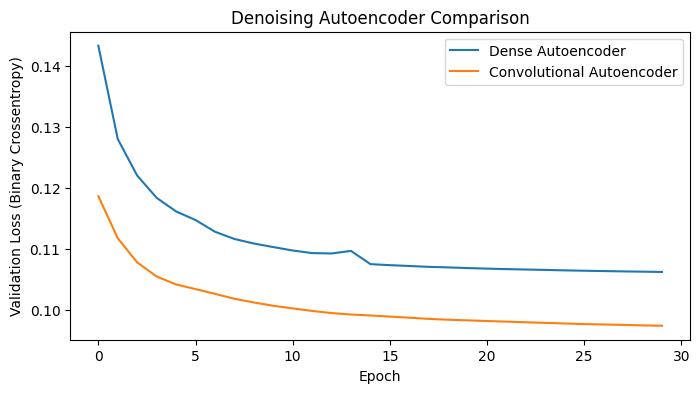

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(dense_history.history['val_loss'], label='Dense Autoencoder')
plt.plot(conv_history.history['val_loss'], label='Convolutional Autoencoder')
plt.xlabel("Epoch")
plt.ylabel("Validation Loss (Binary Crossentropy)")
plt.title("Denoising Autoencoder Comparison")
plt.legend()
plt.show()

### 8a. Denoising Quality Metrics
Loss alone doesn't say much about how good a reconstruction actually looks. PSNR and SSIM are the standard metrics for that in image restoration - PSNR measures how close the reconstruction is in decibels, and SSIM measures structural similarity to the clean image, on a 0-1 scale.

In [11]:
def compute_denoising_metrics(model, noisy_images, clean_images):
    reconstructed = model.predict(noisy_images, verbose=0).reshape(-1, 28, 28, 1)
    clean_reshaped = clean_images.reshape(-1, 28, 28, 1)
    psnr = tf.reduce_mean(tf.image.psnr(clean_reshaped, reconstructed, max_val=1.0))
    ssim = tf.reduce_mean(tf.image.ssim(clean_reshaped, reconstructed, max_val=1.0))
    return float(psnr), float(ssim)

dense_psnr, dense_ssim = compute_denoising_metrics(dense_model, x_test_noisy_flat, x_test_flat)
conv_psnr, conv_ssim = compute_denoising_metrics(conv_model, x_test_noisy_conv, x_test_conv)

metrics_df = pd.DataFrame({
    "Model": ["Dense Autoencoder", "Convolutional Autoencoder"],
    "Final Val Loss (BCE)": [dense_history.history['val_loss'][-1], conv_history.history['val_loss'][-1]],
    "Final Val MSE": [dense_history.history['val_mse'][-1], conv_history.history['val_mse'][-1]],
    "PSNR (dB)": [dense_psnr, conv_psnr],
    "SSIM": [dense_ssim, conv_ssim],
    "Epochs Trained": [len(dense_history.history['loss']), len(conv_history.history['loss'])]
})
metrics_df

,Model,Final Val Loss (BCE),Final Val MSE,PSNR (dB),SSIM,Epochs Trained
0,Dense Autoencoder,0.106249,0.014359,18.834845,0.814814,30
1,Convolutional Autoencoder,0.097438,0.011425,19.772955,0.856700,30


## 9. Denoising Results

In [12]:
def show_denoising_results(model, noisy_images, clean_images, n=8):
    reconstructed = model.predict(noisy_images[:n], verbose=0)
    fig, axes = plt.subplots(3, n, figsize=(14, 5))

    for i in range(n):
        for row, image_set in enumerate([noisy_images, reconstructed, clean_images]):
            ax = axes[row, i]
            ax.imshow(image_set[i].reshape(28, 28), cmap='gray')
            ax.set_xticks([])
            ax.set_yticks([])

    axes[0, 0].set_ylabel("Noisy")
    axes[1, 0].set_ylabel("Denoised")
    axes[2, 0].set_ylabel("Original")
    plt.tight_layout()
    plt.show()

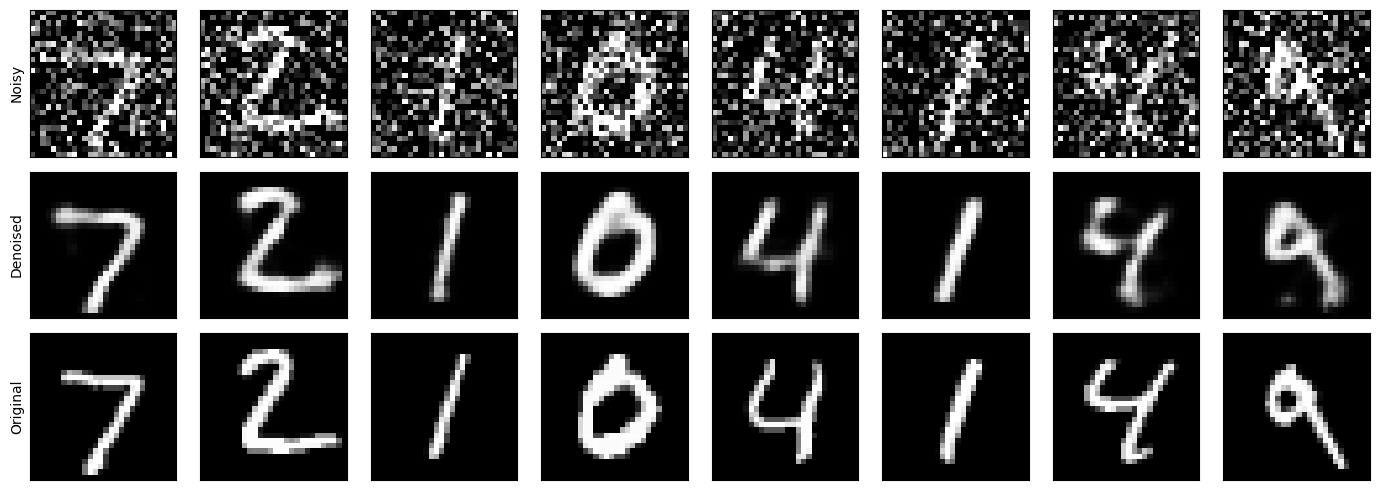

In [13]:
show_denoising_results(dense_model, x_test_noisy_flat, x_test_flat)

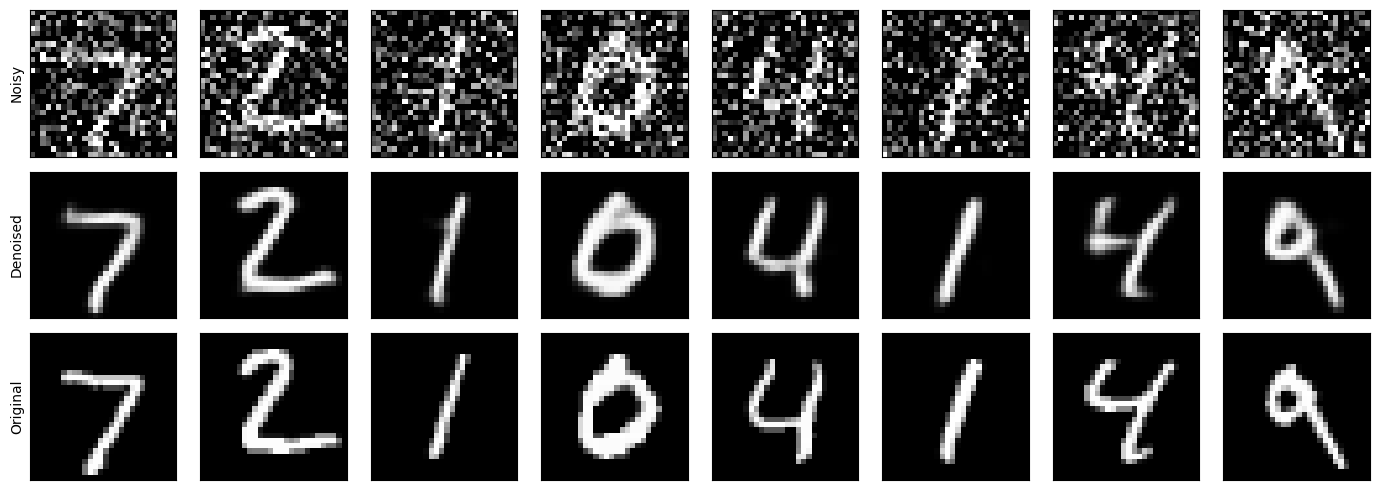

In [14]:
show_denoising_results(conv_model, x_test_noisy_conv, x_test_conv)

## 10. Conclusion
Both systems manage to remove the extra Gaussian noise yet still make the digits easily identifiable.
Sharpness stays intact on drawings where edges stay defined due to how the convolutional method handles flat layouts without reshaping them. Meanwhile, dense networks often produce fuzzier results when rebuilding these images. That blurriness appears regardless of training details because the structure itself shapes what gets preserved.
What really matters isn't just how low the training error goes - PSNR and SSIM show a clearer picture across different systems. Instead of tracking mistakes through numbers, these metrics measure the rebuilt image against the perfect original. Blurriness or detail loss stands out here much better than stats alone could ever reveal. Comparing outputs face-to-face with reference pictures gives a more honest view of recovery success.